O objetivo é repetir todo o processo de segmentação de clientes.

1.  **Carregar os Dados:** Carregue os arquivos `olist_customers_dataset.csv`, `olist_orders_dataset.csv` e `olist_order_items_dataset.csv`.
2.  **Unir as Tabelas (Join):** Use `pd.merge` para criar um único dataframe que contenha, para cada item de pedido, as informações do cliente e da data da compra.
3.  **Construir o Modelo RFM:**
    * **Recência:** Use `order_purchase_timestamp`.
    * **Frequência:** Conte os `order_id` únicos por `customer_unique_id`.
    * **Valor Monetário:** Some a coluna `price`.
    * Execute todo o pipeline: limpeza, cálculo RFM, padronização, Método do Cotovelo e K-Means.
4.  **Analisar e Apresentar os Resultados:**
    * Analise os centróides, crie personas e gere um Snake Plot.
    * **Bônus:** Compare os perfis de clientes do e-commerce brasileiro com os do varejista do Reino Unido.

In [55]:
# @title
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Carregar os Dados
try:
    customers = pd.read_csv('olist_customers_dataset.csv')
    orders = pd.read_csv('olist_orders_dataset.csv')
    order_items = pd.read_csv('olist_order_items_dataset.csv')
    print("Arquivos carregados com sucesso!")
except FileNotFoundError:
    print("Erro: Um ou mais arquivos .csv não foram encontrados.")
    print("Por favor, baixe os arquivos do Kaggle e coloque-os no diretório correto.")
    print("Link: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce")

Arquivos carregados com sucesso!


In [56]:
df_olist = orders.merge(customers, on='customer_id')
df_olist = df_olist.merge(order_items, on='order_id')

print("Tabelas unidas com sucesso!")
print(f"Formato do DataFrame final: {df_olist.shape}")

print("\nPrimeiras 5 linhas do DataFrame unido:")
print(df_olist.head())

print("\nInformações gerais do DataFrame:")
df_olist.info()

Tabelas unidas com sucesso!
Formato do DataFrame final: (112650, 18)

Primeiras 5 linhas do DataFrame unido:
                           order_id                       customer_id order_status order_purchase_timestamp    order_approved_at order_delivered_carrier_date order_delivered_customer_date order_estimated_delivery_date                customer_unique_id  customer_zip_code_prefix            customer_city customer_state  order_item_id                        product_id                         seller_id  shipping_limit_date   price  freight_value
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15          2017-10-04 19:55:00           2017-10-10 21:25:13           2017-10-18 00:00:00  7c396fd4830fd04220f754e42b4e5bff                      3149                sao paulo             SP              1  87285b34884572647811a353c7ac498a  3504c0cb71d7fa48d967e0e4c94d59d9  2017-10-06 11:07:15  29.990          8.720
1

In [57]:
df_olist.describe()

,customer_zip_code_prefix,order_item_id,price,freight_value
count,112650.000,112650.000,112650.000,112650.000
mean,35119.309,1.198,120.654,19.990
std,29866.121,0.705,183.634,15.806
min,1003.000,1.000,0.850,0.000
25%,11310.000,1.000,39.900,13.080
50%,24340.000,1.000,74.990,16.260
75%,59028.750,1.000,134.900,21.150
max,99990.000,21.000,6735.000,409.680


In [58]:
print(df_olist.isnull().sum())

# Convertendo a coluna de data para o formato datetime
df_olist['order_purchase_timestamp'] = pd.to_datetime(df_olist['order_purchase_timestamp'])

print("\nTipo da coluna 'order_purchase_timestamp' após conversão:")
print(df_olist.dtypes['order_purchase_timestamp'])

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
dtype: int64

Tipo da coluna 'order_purchase_timestamp' após conversão:
datetime64[ns]


# RFM

In [59]:
snapshot_date = df_olist['order_purchase_timestamp'].max() + dt.timedelta(days=1)
print(f"Data de Referência (Snapshot Date): {snapshot_date}")

# Calculando os valores RFM para cada cliente
rfm_olist = df_olist.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda date: (snapshot_date - date.max()).days, # Recencia
    'order_id': 'nunique', # Frequencia
    'price': 'sum' # Valor Monetário
})

# Renomeando as colunas para o padrao do RFM
rfm_olist.rename(columns={'order_purchase_timestamp': 'Recency',
                          'order_id': 'Frequency',
                          'price': 'Monetary'}, inplace=True)

print("\nTabela RFM gerada para o dataset Olist:")
print(rfm_olist.head())

print("\nEstatísticas descritivas da tabela RFM:")
print(rfm_olist.describe().T)

Data de Referência (Snapshot Date): 2018-09-04 09:06:57

Tabela RFM gerada para o dataset Olist:
                                  Recency  Frequency  Monetary
customer_unique_id                                            
0000366f3b9a7992bf8c76cfdf3221e2      116          1   129.900
0000b849f77a49e4a4ce2b2a4ca5be3f      119          1    18.900
0000f46a3911fa3c0805444483337064      542          1    69.000
0000f6ccb0745a6a4b88665a16c9f078      326          1    25.990
0004aac84e0df4da2b147fca70cf8255      293          1   180.000

Estatísticas descritivas da tabela RFM:
              count    mean     std   min     25%     50%     75%       max
Recency   95420.000 243.600 153.160 1.000 119.000 224.000 353.000   729.000
Frequency 95420.000   1.034   0.211 1.000   1.000   1.000   1.000    16.000
Monetary  95420.000 142.440 217.656 0.850  47.900  89.900 155.000 13440.000


# Padronização

In [60]:
scaler = StandardScaler()

# transformando os dados
rfm_olist_scaled = scaler.fit_transform(rfm_olist)

# Convertendo de volta para um DataFrame para facilitar a visualização
rfm_olist_scaled_df = pd.DataFrame(rfm_olist_scaled, columns=rfm_olist.columns, index=rfm_olist.index)

print("Estatísticas descritivas após a padronização:")
print(rfm_olist_scaled_df.describe().T)

Estatísticas descritivas após a padronização:
              count   mean   std    min    25%    50%    75%    max
Recency   95420.000 -0.000 1.000 -1.584 -0.814 -0.128  0.714  3.169
Frequency 95420.000  0.000 1.000 -0.161 -0.161 -0.161 -0.161 70.851
Monetary  95420.000  0.000 1.000 -0.651 -0.434 -0.241  0.058 61.095


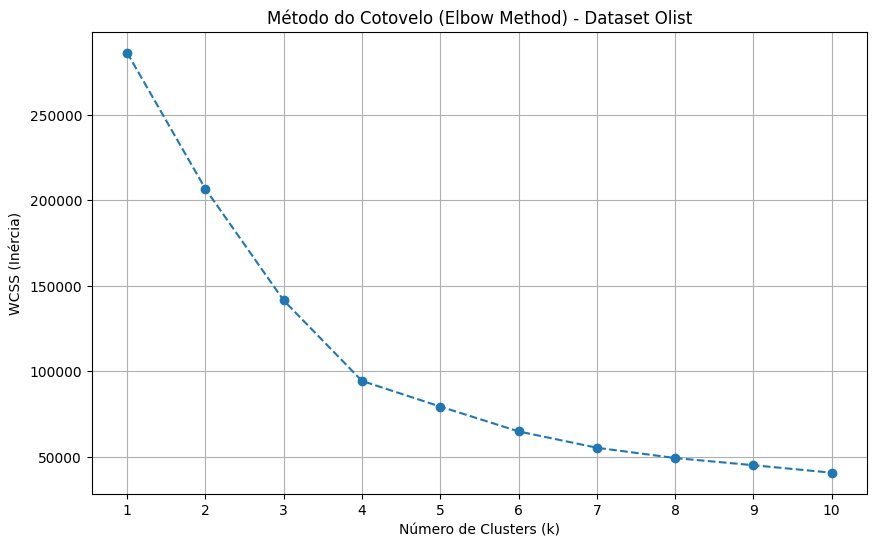

In [61]:
# Metodo do Cotovelo
wcss = []
range_k = range(1, 11)

for i in range_k:
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(rfm_olist_scaled)
    wcss.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range_k, wcss, marker='o', linestyle='--')
plt.title('Método do Cotovelo (Elbow Method) - Dataset Olist')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS (Inércia)')
plt.xticks(range_k)
plt.grid(True)
plt.show()

A partir do 3, para a formação de clusters, é possível ver uma queda acentuada. Após o 4, a curva começa a achatar e, depois disso, a redução fica menor, o que sugere que o valor de 4 clusters pode ser o ideal.

In [62]:
# Treinando o modelo
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)

# Ajustando o modelo e prevendo os clusters
clusters = kmeans.fit_predict(rfm_olist_scaled)

# Adicionando a coluna de clusters
rfm_olist['Cluster'] = clusters

print("Tabela RFM com a coluna de Cluster:")
print(rfm_olist.head())

Tabela RFM com a coluna de Cluster:
                                  Recency  Frequency  Monetary  Cluster
customer_unique_id                                                     
0000366f3b9a7992bf8c76cfdf3221e2      116          1   129.900        0
0000b849f77a49e4a4ce2b2a4ca5be3f      119          1    18.900        0
0000f46a3911fa3c0805444483337064      542          1    69.000        1
0000f6ccb0745a6a4b88665a16c9f078      326          1    25.990        1
0004aac84e0df4da2b147fca70cf8255      293          1   180.000        1


# Criando Personas para Cada Cluster

In [63]:
# Calculando a media dos valores RFM para cada cluster
segment_analysis = rfm_olist.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

print("Análise dos segmentos (médias RFM por cluster):")
print(segment_analysis)

cluster_names = {
    0: 'Clientes Adormecidos',
    1: 'Clientes Campeões',
    2: 'Clientes em Risco',
    3: 'Novos Clientes'
}

# Mapeando os nomes para a coluna de cluster
rfm_olist['Segment'] = rfm_olist['Cluster'].map(cluster_names)

print("\nContagem de clientes por segmento:")
print(rfm_olist['Segment'].value_counts())

print("\nAnálise final dos segmentos (médias RFM por segmento):")
print(rfm_olist.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().sort_values(by='Monetary', ascending=False))

Análise dos segmentos (médias RFM por cluster):
         Recency  Frequency  Monetary
Cluster                              
0        133.519      1.000   113.597
1        393.691      1.000   114.481
2        226.185      2.115   243.050
3        244.352      1.014  1145.315

Contagem de clientes por segmento:
Segment
Clientes Adormecidos    51886
Clientes Campeões       38378
Clientes em Risco        2883
Novos Clientes           2273
Name: count, dtype: int64

Análise final dos segmentos (médias RFM por segmento):
                      Recency  Frequency  Monetary
Segment                                           
Novos Clientes        244.352      1.014  1145.315
Clientes em Risco     226.185      2.115   243.050
Clientes Campeões     393.691      1.000   114.481
Clientes Adormecidos  133.519      1.000   113.597


# Visualizando os Segmentos

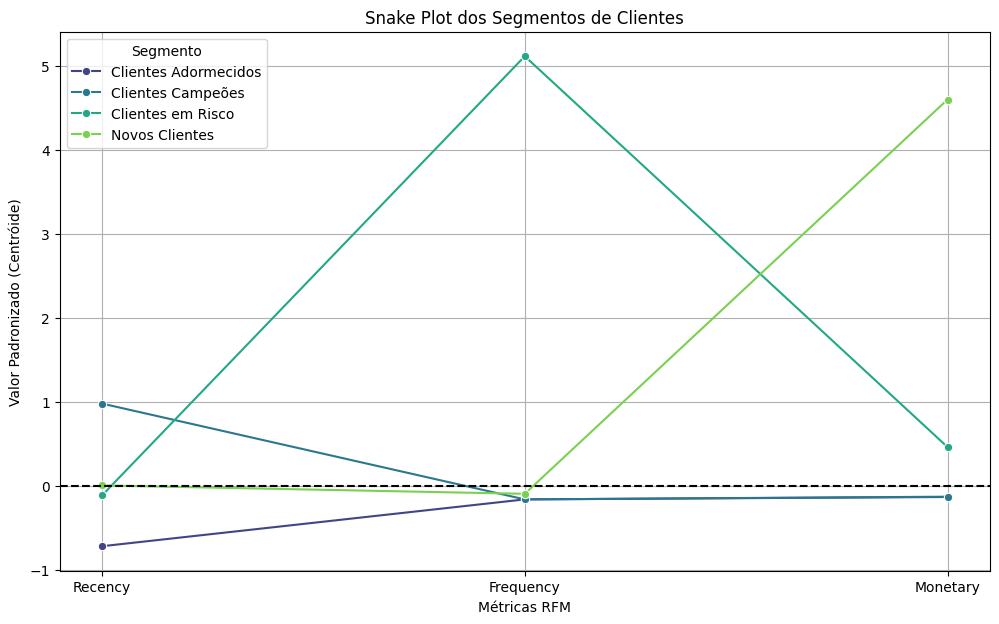

In [64]:
# Obtendo os centróides dos clusters
centroids_scaled = kmeans.cluster_centers_

# Criando um DataFrame com os centróides padronizados para o plot
centroids_scaled_df = pd.DataFrame(centroids_scaled, columns=['Recency', 'Frequency', 'Monetary'])
centroids_scaled_df['Segment'] = list(cluster_names.values())

datamart_melt = pd.melt(centroids_scaled_df,
                        id_vars='Segment',
                        value_vars=['Recency', 'Frequency', 'Monetary'],
                        var_name='Metric',
                        value_name='Value')

# Snake Plot
plt.figure(figsize=(12, 7))
sns.lineplot(data=datamart_melt, x='Metric', y='Value', hue='Segment', palette='viridis', marker='o')
plt.title('Snake Plot dos Segmentos de Clientes')
plt.xlabel('Métricas RFM')
plt.ylabel('Valor Padronizado (Centróide)')
plt.legend(title='Segmento')
plt.grid(True)
plt.axhline(0, color='black', linestyle='--') # Linha da média
plt.show()

O gráfico Snake Plot exibe o perfil padronizado de quatro segmentos de clientes com base nas métricas RFM (Recência, Frequência e Valor Monetário). A linha zero representa o comportamento médio da população de clientes.

1. Clientes Campeões

*    Recência: Abaixo da média, indicando compra recente;
*    Frequência: Extremamente acima da média, sendo o valor mais alto do gráfico. Indica alta lealdade e compras repetidas;
*    Monetário: Acima da média, indicando bom valor de gasto.

**Conclusão**: É um perfil de alta frequência e alto engajamento.

2. Novos Clientes

*    Recência: Abaixo da média, indicando compra recente;

*   Frequência: Abaixo da média, característico de clientes com poucas compras;

*   Monetário: Significativamente acima da média, sendo o segundo maior valor do gráfico. Indica alto valor por transação.

**Conclusão**: Perfil de cliente recente de alto valor gasto em poucas transações.

3. Clientes em Risco

*    Recência: Acima da média, sendo o valor mais alto do gráfico. Indica um longo período desde a última compra.

*    Frequência: Abaixo da média.

*    Monetário: Abaixo da média.

**Conclusão**: Perfil de cliente inativo ou perdido, com baixo engajamento histórico.

4. Clientes Adormecidos

*    Recência: Abaixo da média, indicando compra recente.

*    Frequência: Abaixo da média.

*    Monetário: Abaixo da média.

**Conclusão**: Perfil de cliente recente, porém com baixo valor e baixa frequência, indicando baixo engajamento geral.

# Web-br VS Reino Unido

A análise mostra que os clientes do ecommerce br e da loja do Reino Unido são muito diferentes, o que reflete o tipo de negócio de cada um. No Brasil, a grande maioria dos clientes compra apenas uma vez. Por isso, não adianta muito separá-los pela frequência de compra. É mais útil agrupá-los por quando fizeram sua última compra e, principalmente, quanto gastaram nela. É por isso que encontramos grupos importantes como os "Novos Clientes" e, especialmente, os "Clientes de Alto Valor", que gastaram muito dinheiro em sua única visita. Já a loja do Reino Unido é diferente, pois vende muito para outras empresas que compram para revender (atacadistas). Para eles, o mais importante seria a frequência com que compram, criando um forte grupo de "Clientes Campeões" que fazem pedidos o tempo todo, um perfil que quase não existe no e-commerce brasileiro.

Com base nisso, a sugestão para o e-commerce brasileiro é dar atenção especial ao grupo de "Clientes de Alto Valor". Em vez de gastar energia tentando trazer de volta todos que fizeram uma única compra pequena, é mais inteligente focar naqueles que já mostraram que confiam na loja e estão dispostos a gastar bastante. A estratégia seria oferecer um tratamento diferenciado logo após essa grande primeira compra, sugerindo produtos que combinem com o que levaram ou dando acesso a vantagens exclusivas. O objetivo é dar a eles um bom motivo para fazer uma segunda compra, criando um novo tipo de cliente ideal: aquele que não só gasta muito, mas também se torna fiel.